=== Scaled Dot-Product Attention ===

Q shape:       torch.Size([1, 1, 5, 8])
K shape:       torch.Size([1, 1, 5, 8])
V shape:       torch.Size([1, 1, 5, 8])
Output shape:  torch.Size([1, 1, 5, 8])
Weights shape: torch.Size([1, 1, 5, 5])

Attention weights (row sums = 1.0):
[[0.207 0.146 0.269 0.1   0.279]
 [0.051 0.204 0.367 0.208 0.171]
 [0.131 0.078 0.48  0.053 0.257]
 [0.238 0.173 0.085 0.228 0.276]
 [0.059 0.574 0.028 0.232 0.107]]

Row sums: [1. 1. 1. 1. 1.]


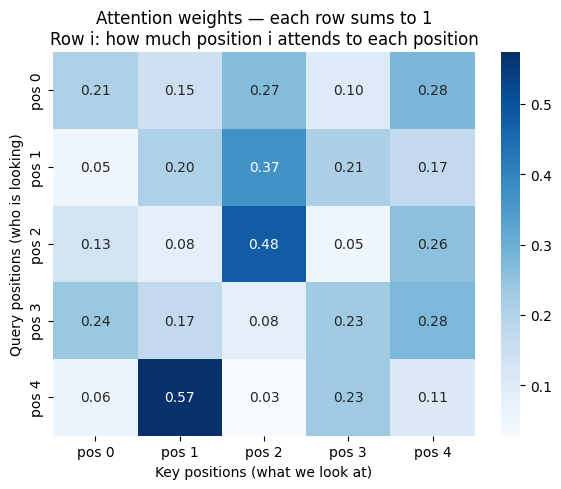

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# ── The core operation — 10 lines ─────────────────────────
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Q: (batch, heads, seq_len, d_k)  — queries
    K: (batch, heads, seq_len, d_k)  — keys
    V: (batch, heads, seq_len, d_v)  — values

    Returns:
        output:  (batch, heads, seq_len, d_v)
        weights: (batch, heads, seq_len, seq_len)
    """
    d_k = Q.shape[-1]

    # Step 1: compute attention scores
    # Q @ K.T → how much does each query match each key?
    scores = Q @ K.transpose(-2, -1) / np.sqrt(d_k)
    # shape: (batch, heads, seq_len, seq_len)

    # Step 2: optional mask (prevents looking at future tokens)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))

    # Step 3: softmax → attention weights (sum to 1)
    weights = F.softmax(scores, dim=-1)
    # Each row is a probability distribution over positions

    # Step 4: weighted sum of values
    output = weights @ V
    # shape: (batch, heads, seq_len, d_v)

    return output, weights


# ── Testing with a simple example ─────────────────────────────
torch.manual_seed(42)

batch, seq_len, d_k = 1, 5, 8

Q = torch.randn(batch, 1, seq_len, d_k)
K = torch.randn(batch, 1, seq_len, d_k)
V = torch.randn(batch, 1, seq_len, d_k)

output, weights = scaled_dot_product_attention(Q, K, V)

print("=== Scaled Dot-Product Attention ===\n")
print(f"Q shape:       {Q.shape}")
print(f"K shape:       {K.shape}")
print(f"V shape:       {V.shape}")
print(f"Output shape:  {output.shape}")
print(f"Weights shape: {weights.shape}")
print(f"\nAttention weights (row sums = 1.0):")
w = weights[0, 0].detach().numpy()
print(np.round(w, 3))
print(f"\nRow sums: {w.sum(axis=1).round(3)}")

# Visualising attention pattern
plt.figure(figsize=(6, 5))
sns.heatmap(w, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'pos {i}' for i in range(seq_len)],
            yticklabels=[f'pos {i}' for i in range(seq_len)])
plt.title('Attention weights — each row sums to 1\n'
          'Row i: how much position i attends to each position')
plt.xlabel('Key positions (what we look at)')
plt.ylabel('Query positions (who is looking)')
plt.tight_layout()
plt.show()

=== Multi-Head Attention ===

Input:   torch.Size([2, 10, 64])   (batch, seq_len, d_model)
Output:  torch.Size([2, 10, 64])  (batch, seq_len, d_model)
Weights: torch.Size([2, 4, 10, 10])
         (batch, num_heads, seq_len, seq_len)

Parameters: 16,640
  4 heads × 16 dim each = 64 total dim


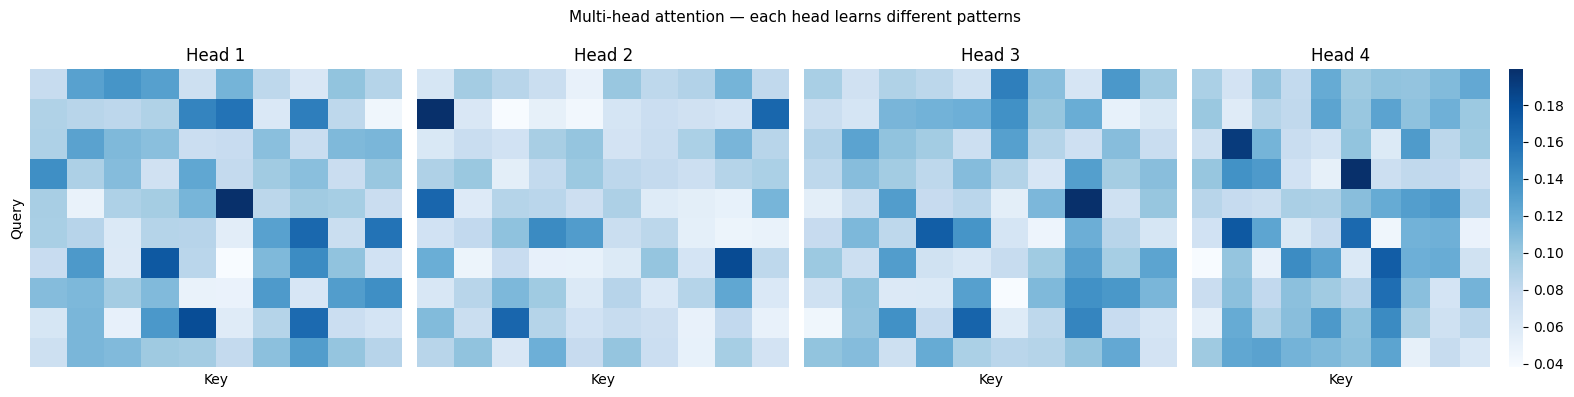


Notice: each head has a different attention pattern
Head 1 might focus on local patterns
Head 2 might focus on global patterns
The model learns which patterns are useful


In [2]:
class MultiHeadAttention(nn.Module):
    """
    Instead of one attention, run H attention heads in parallel.
    Each head learns to attend to different aspects of the input.

    Head 1 might focus on: frequency transitions
    Head 2 might focus on: amplitude patterns
    Head 3 might focus on: sleep spindle timing
    """

    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model    = d_model
        self.num_heads  = num_heads
        self.d_k        = d_model // num_heads  # dim per head

        # Learned projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # Output projection
        self.W_o = nn.Linear(d_model, d_model)

    def split_heads(self, x):
        """
        (batch, seq_len, d_model)
        → (batch, num_heads, seq_len, d_k)
        """
        batch, seq_len, _ = x.shape
        x = x.reshape(batch, seq_len,
                       self.num_heads, self.d_k)
        return x.transpose(1, 2)

    def forward(self, x, mask=None):
        batch, seq_len, _ = x.shape

        # Project input to Q, K, V
        Q = self.split_heads(self.W_q(x))
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # Attention across all heads simultaneously
        attn_out, weights = scaled_dot_product_attention(
            Q, K, V, mask
        )

        # Concatenate heads
        attn_out = attn_out.transpose(1, 2).reshape(
            batch, seq_len, self.d_model
        )

        # Final projection
        return self.W_o(attn_out), weights


# ── Testing ───────────────────────────────────────────────────
mha = MultiHeadAttention(d_model=64, num_heads=4)

x = torch.randn(2, 10, 64)   # batch=2, seq=10, features=64
out, weights = mha(x)

total = sum(p.numel() for p in mha.parameters())

print("=== Multi-Head Attention ===\n")
print(f"Input:   {x.shape}   (batch, seq_len, d_model)")
print(f"Output:  {out.shape}  (batch, seq_len, d_model)")
print(f"Weights: {weights.shape}")
print(f"         (batch, num_heads, seq_len, seq_len)")
print(f"\nParameters: {total:,}")
print(f"  4 heads × {64//4} dim each = 64 total dim")

# Visualising each head's attention pattern
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
w = weights[0].detach().numpy()  # first sample

for h in range(4):
    sns.heatmap(w[h], cmap='Blues', ax=axes[h],
                xticklabels=False, yticklabels=False,
                cbar=h==3)
    axes[h].set_title(f'Head {h+1}')
    axes[h].set_xlabel('Key')
    if h == 0:
        axes[h].set_ylabel('Query')

plt.suptitle('Multi-head attention — each head learns '
             'different patterns', fontsize=11)
plt.tight_layout()
plt.show()

print("\nNotice: each head has a different attention pattern")
print("Head 1 might focus on local patterns")
print("Head 2 might focus on global patterns")
print("The model learns which patterns are useful")

In [3]:
class TransformerBlock(nn.Module):
    """
    One transformer block = attention + feedforward + residuals

    The residual connections (+x) are critical:
    they let gradients flow directly through,
    enabling very deep networks to train
    """

    def __init__(self, d_model, num_heads, ff_dim,
                 dropout=0.1):
        super().__init__()

        # Multi-head attention
        self.attention = MultiHeadAttention(d_model, num_heads)

        # Feed-forward network
        # applied independently to each position
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, d_model)
        )

        # Layer normalisation
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Sub-layer 1: attention + residual + norm
        attn_out, weights = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        # Sub-layer 2: feedforward + residual + norm
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x, weights


# ── Testing ───────────────────────────────────────────────────
block = TransformerBlock(
    d_model=64,
    num_heads=4,
    ff_dim=256,
    dropout=0.1
)

x   = torch.randn(2, 10, 64)
out, weights = block(x)

total = sum(p.numel() for p in block.parameters())

print("=== Transformer Block ===\n")
print(f"Input:  {x.shape}")
print(f"Output: {out.shape}  (same shape as input)")
print(f"Parameters: {total:,}\n")
print("Components:")
print(f"  MultiHeadAttention: {sum(p.numel() for p in block.attention.parameters()):,}")
print(f"  FeedForward:        {sum(p.numel() for p in block.ff.parameters()):,}")
print(f"  LayerNorms:         {sum(p.numel() for p in list(block.norm1.parameters()) + list(block.norm2.parameters())):,}")
print(f"\nKey insight: output shape = input shape")
print("This lets you stack blocks: output of one")
print("feeds directly into the next")

=== Transformer Block ===

Input:  torch.Size([2, 10, 64])
Output: torch.Size([2, 10, 64])  (same shape as input)
Parameters: 49,984

Components:
  MultiHeadAttention: 16,640
  FeedForward:        33,088
  LayerNorms:         256

Key insight: output shape = input shape
This lets you stack blocks: output of one
feeds directly into the next


=== Attention EEG Classifier ===

Input:        torch.Size([4, 3000])
Output:       torch.Size([4, 5])
Attn weights: torch.Size([4, 4, 10, 10])
              (batch, heads, windows, windows)
Parameters:   58,373



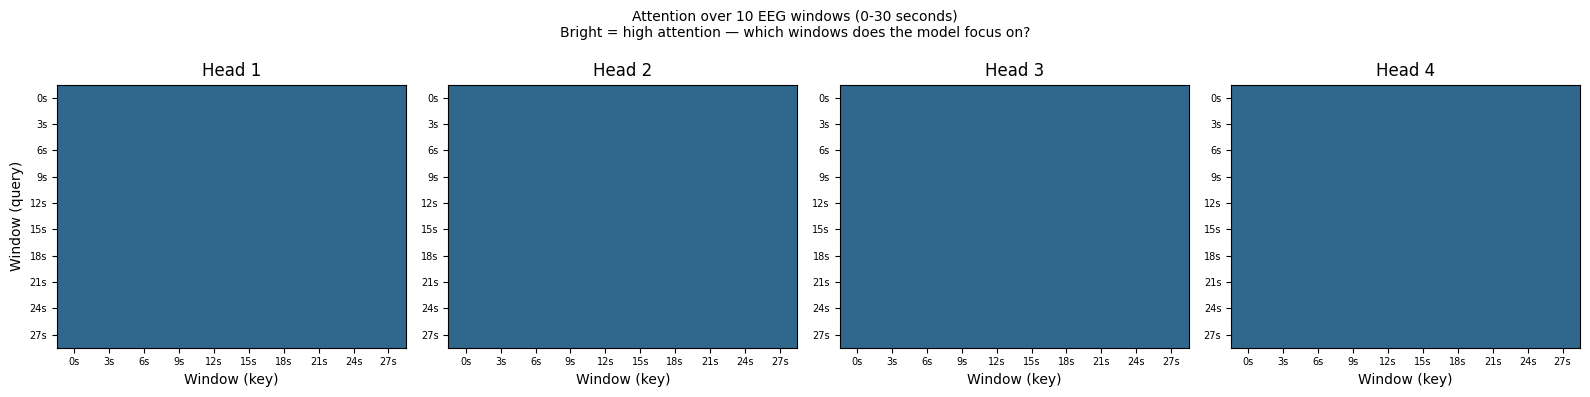

This is Experiment 004 — attention over EEG windows
In a trained model, bright spots = the windows that
most strongly indicate the sleep stage
For REM: theta burst windows should be brightest


In [4]:
class AttentionEEGClassifier(nn.Module):
    """
    Add self-attention to CNN-LSTM hybrid.
    After CNN extracts features from each window,
    attention decides WHICH windows matter most
    for sleep stage classification.

    This is Experiment 004 preview.
    """

    def __init__(self,
                 n_windows=10,
                 window_size=300,
                 cnn_dim=128,
                 d_model=64,
                 num_heads=4,
                 n_classes=5,
                 dropout=0.3):
        super().__init__()

        self.n_windows   = n_windows
        self.window_size = window_size

        # CNN — same as Experiment 003
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )

        # Project CNN output to d_model
        self.cnn_proj = nn.Linear(128, d_model)

        # Self-attention over CNN windows
        # "which 3-second windows matter most?"
        self.attention = MultiHeadAttention(
            d_model=d_model,
            num_heads=num_heads
        )
        self.norm = nn.LayerNorm(d_model)

        # Classifier on attended features
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, n_classes)
        )

    def forward(self, x):
        batch = x.shape[0]

        # CNN on each window
        x = x.reshape(batch, self.n_windows, self.window_size)
        features = []
        for t in range(self.n_windows):
            w   = x[:, t, :].unsqueeze(1)  # (B,1,300)
            f   = self.cnn(w).squeeze(-1)   # (B,128)
            f   = self.cnn_proj(f)          # (B,d_model)
            features.append(f)

        # Stack: (batch, n_windows, d_model)
        seq = torch.stack(features, dim=1)

        # Self-attention over windows
        attn_out, weights = self.attention(seq)
        seq = self.norm(seq + attn_out)

        # Pool over windows → single vector
        pooled = seq.mean(dim=1)  # (batch, d_model)

        return self.classifier(pooled), weights


# ── Testing shapes ────────────────────────────────────────────
attn_model = AttentionEEGClassifier()
dummy       = torch.randn(4, 3000)
out, weights = attn_model(dummy)

total = sum(p.numel() for p in attn_model.parameters())

print("=== Attention EEG Classifier ===\n")
print(f"Input:        {dummy.shape}")
print(f"Output:       {out.shape}")
print(f"Attn weights: {weights.shape}")
print(f"              (batch, heads, windows, windows)")
print(f"Parameters:   {total:,}\n")

# Visualising attention over EEG windows
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
w = weights[0].detach().numpy()  # first sample, all heads

for h in range(4):
    axes[h].imshow(w[h], cmap='viridis',
                   aspect='auto', vmin=0, vmax=0.3)
    axes[h].set_title(f'Head {h+1}')
    axes[h].set_xlabel('Window (key)')
    if h == 0:
        axes[h].set_ylabel('Window (query)')
    axes[h].set_xticks(range(10))
    axes[h].set_yticks(range(10))
    axes[h].set_xticklabels(
        [f'{i*3}s' for i in range(10)], fontsize=7)
    axes[h].set_yticklabels(
        [f'{i*3}s' for i in range(10)], fontsize=7)

plt.suptitle(
    'Attention over 10 EEG windows (0-30 seconds)\n'
    'Bright = high attention — which windows does '
    'the model focus on?',
    fontsize=10
)
plt.tight_layout()
plt.show()

print("This is Experiment 004 — attention over EEG windows")
print("In a trained model, bright spots = the windows that")
print("most strongly indicate the sleep stage")
print("For REM: theta burst windows should be brightest")

In [5]:
# ── Why attention changes everything ──────────────────────

summary = """
=== Attention — What It Does ===

1. SELF-ATTENTION
   Every position looks at every other position
   and decides what's relevant.
   
   EEG application:
   Window at t=15s looks at all other windows →
   "the theta burst at t=6s is highly relevant
    to understanding what's happening at t=15s"

2. MULTI-HEAD ATTENTION
   Run H attention operations in parallel.
   Each head specialises in different patterns.
   
   EEG application:
   Head 1: attends to frequency transitions
   Head 2: attends to amplitude patterns  
   Head 3: attends to spindle/burst timing
   Head 4: attends to slow wave patterns

3. WHY IT BEATS LSTM FOR LONG SEQUENCES
   LSTM:      information travels step by step
              early information gradually fades
   Attention: every position directly connects
              to every other — nothing fades

4. WHY IT MATTERS FOR LUCID
   Current pipeline: LSTM reads 30s of EEG sequentially
   Future pipeline:  Transformer reads 8 hours of sleep
                     and understands the full night's
                     architecture — which cycle, which
                     transition, optimal trigger moment
"""

print(summary)


=== Attention — What It Does ===

1. SELF-ATTENTION
   Every position looks at every other position
   and decides what's relevant.

   EEG application:
   Window at t=15s looks at all other windows →
   "the theta burst at t=6s is highly relevant
    to understanding what's happening at t=15s"

2. MULTI-HEAD ATTENTION
   Run H attention operations in parallel.
   Each head specialises in different patterns.

   EEG application:
   Head 1: attends to frequency transitions
   Head 2: attends to amplitude patterns  
   Head 3: attends to spindle/burst timing
   Head 4: attends to slow wave patterns

3. WHY IT BEATS LSTM FOR LONG SEQUENCES
   LSTM:      information travels step by step
              early information gradually fades
   Attention: every position directly connects
              to every other — nothing fades

4. WHY IT MATTERS FOR LUCID
   Current pipeline: LSTM reads 30s of EEG sequentially
   Future pipeline:  Transformer reads 8 hours of sleep
                     and u

In [6]:
# "Attention Is All You Need" — Vaswani et al., 2017
# The paper that changed everything

paper_summary = """
=== "Attention Is All You Need" (2017) ===

Before this paper:
  Best NLP models = LSTM + CNN combinations
  Translation quality: good but slow
  Long-range dependencies: hard to capture

The key insight:
  You don't need recurrence at all.
  Attention alone can capture everything.
  And attention parallelises — LSTMs cannot.

What it introduced:
  - Scaled dot-product attention
  - Multi-head attention  
  - Positional encoding (since attention has no order)
  - Encoder-decoder with pure attention

What it became:
  2018: BERT (bidirectional transformer)
  2019: GPT-2
  2020: GPT-3 (175B parameters)
  2022: ChatGPT
  2023: GPT-4, Claude, Gemini
  2024: Multimodal transformers
  Future: LUCID dream generation layer

The 8 authors who wrote this paper in 2017 
could not have predicted that their architecture
would become the foundation of every major AI system
in the next decade.

You now understand how it works from first principles.
"""

print(paper_summary)


=== "Attention Is All You Need" (2017) ===

Before this paper:
  Best NLP models = LSTM + CNN combinations
  Translation quality: good but slow
  Long-range dependencies: hard to capture

The key insight:
  You don't need recurrence at all.
  Attention alone can capture everything.
  And attention parallelises — LSTMs cannot.

What it introduced:
  - Scaled dot-product attention
  - Multi-head attention  
  - Positional encoding (since attention has no order)
  - Encoder-decoder with pure attention

What it became:
  2018: BERT (bidirectional transformer)
  2019: GPT-2
  2020: GPT-3 (175B parameters)
  2022: ChatGPT
  2023: GPT-4, Claude, Gemini
  2024: Multimodal transformers
  Future: LUCID dream generation layer

The 8 authors who wrote this paper in 2017 
could not have predicted that their architecture
would become the foundation of every major AI system
in the next decade.

You now understand how it works from first principles.

